## Imports

In [142]:
# ricordarsi di runnare pip freeze > requirements.txt prima di finire progetto

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## DataSet Import

In [143]:
df = pd.read_csv("../data/raw/raw_data.csv", sep=';')

df.head()

# DF Dimension, types of columns, null values
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7726 entries, 0 to 7725
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   WO                                     7726 non-null   int64  
 1   FASE                                   7726 non-null   int64  
 2   ARTICOLO                               7719 non-null   float64
 3   Descrizione Articolo                   7719 non-null   str    
 4   ID DAD                                 7726 non-null   int64  
 5   C.d.L. Prev                            7719 non-null   float64
 6   Descrizione Centro di Lavoro previsto  7719 non-null   str    
 7   C.d.L. Effett                          7619 non-null   float64
 8   Cod CIC                                7720 non-null   str    
 9   Descrizione Macchina                   7720 non-null   str    
 10  Data fine                              7726 non-null   str    
 11  Ora fine       

WO                                         0
FASE                                       0
ARTICOLO                                   7
Descrizione Articolo                       7
ID DAD                                     0
C.d.L. Prev                                7
Descrizione Centro di Lavoro previsto      7
C.d.L. Effett                            107
Cod CIC                                    6
Descrizione Macchina                       6
Data fine                                  0
Ora fine                                   0
Scarti Materiale                           0
Scarti Lavoraz.                            0
Pezzi Ripassati                            0
Pezzi da Avanzare                          0
Pezzi Mancanti                             0
Tot pezzi Contegg.                         0
Qta totale su AS/400                       0
Qta opera su AS/400                        0
Tempo Attrezz. ORE                         0
Tempo Lavoraz. ORE                         0
Durata Sos

## Data Cleaning

In [144]:
# converting data format from ita to eng
# union of colums 'Data fine' 'Ora fine' into one column
df["Data_Ora_Fine"] = pd.to_datetime(df["Data fine"] + " " + df["Ora fine"], format="%d/%m/%Y %H:%M:%S")
df = df.drop(["Data fine", "Ora fine"], axis=1)

# conversion str to int
df["Tempo Attrezz. ORE"] = (
    df["Tempo Attrezz. ORE"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)
df["Tempo Lavoraz. ORE"] = (
    df["Tempo Lavoraz. ORE"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)
df["Durata Soste Ore"] = (
    df["Durata Soste Ore"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)
df["Buon Tempo Ciclo MIN."] = (
    df["Buon Tempo Ciclo MIN."]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)
df["Tempo Macc AS400 ORE"] = (
    df["Tempo Macc AS400 ORE"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)
df["Tempo Attr AS400 ORE"] = (
    df["Tempo Attr AS400 ORE"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)

# Convert min to h
df["Buon Tempo Ciclo MIN."] = df["Buon Tempo Ciclo MIN."] / 60
df.rename(columns={"Buon Tempo Ciclo MIN.": "Buon Tempo Ciclo ORE"}, inplace=True)

# remove useless rows
df = df[df["Tot pezzi Contegg."] > 0]
df = df[df["Tempo Lavoraz. ORE"] > 0]

# since they're not much drop the rows that contain null values
df = df.dropna()

# creating new variables
df["Tempo_Teorico_TOT_ORE"] = df["Buon Tempo Ciclo ORE"] * df["Tot pezzi Contegg."]
df["Indice_Inefficienza"] = df["Tempo Lavoraz. ORE"] / df["Tempo_Teorico_TOT_ORE"]
df = df[df["Tempo_Teorico_TOT_ORE"] > 0]

# ****** APPUNTI ******
# primo dato pulito 2025-01-07 09:33:46 ultimo dato pulito 2026-02-24 11:13:01 
# appunti tesi:
# impostando un valore arbitrario come 10 in df = df[df["Indice_Inefficienza"] < 10]
# si ottenevano degli errori nei dati in quanto si ha una media = 1.33 e una 
# deviazione standard = 0.48
# ovvero in media le macchine ci mettono il 33% in più rispetto al tempo teorico
# e c'è un alta variabilità tra il tempo di produzione delle macchine (0.48)
# con una variabilità del (0.48 / 1.33) × 100 = 36% rispetto al valore medio
# 1 deviazione standard → 1.33 + 0.48 = 1.81
# 2 deviazioni → 1.33 + (2 × 0.48) = 2.29
# 3 deviazioni → 1.33 + (3 × 0.48) = 2.77
# dunque:
# > 1.8	inefficienza anomala leggera
# > 2.3	inefficienza forte
# > 2.8	quasi sicuramente errore o caso eccezionale
# dove il valore più alto era di 8.07 che è chiaramente un errore o un caso speciale
# in quanto significherebbe che una macchina ci ha impegato 8 volte tanto rispetto al tempo teorico
# dunque ho calcolato il valore sul quale basarsi per scartare i dati speciali o di errore
# con il metodo dei quartili in questo modo si ha un valore massimo di 2.5
# --------------------------------------------------------------------------------------------------
# quantita di wo che non hanno un benchmark di tempo ovvero quanto ci si aspetta che
# la macchina ci impieghi a produrre il wo (nel gestionale)
# df[df["Tempo Macc AS400 ORE"] == 0].shape[0] / len(df)
# risultato: 0.17410643367752185 il 17% dei wo nei dati puliti hanno benchmark 0.0

# Range Interquartile (IQR)
Q1 = df["Indice_Inefficienza"].quantile(0.25)
Q3 = df["Indice_Inefficienza"].quantile(0.75)
IQR = Q3 - Q1

# upperbound calculation to discard values
upper_bound = Q3 + 1.5 * IQR
df = df[df["Indice_Inefficienza"] < upper_bound]

# lowerbound calculation to discard values
lower_bound = Q1 - 1.5 * IQR
df = df[df["Indice_Inefficienza"] > lower_bound]

# creating csv file of clean data
df.to_csv("../data/processed/clean_data.csv", index=False)

df = df.sort_values("Data_Ora_Fine")

## Graphs

In [145]:
df = pd.read_csv("../data/processed/clean_data.csv")
sns.set_theme(style="whitegrid", palette="muted")

## Histogram of the Global Inefficiency Index

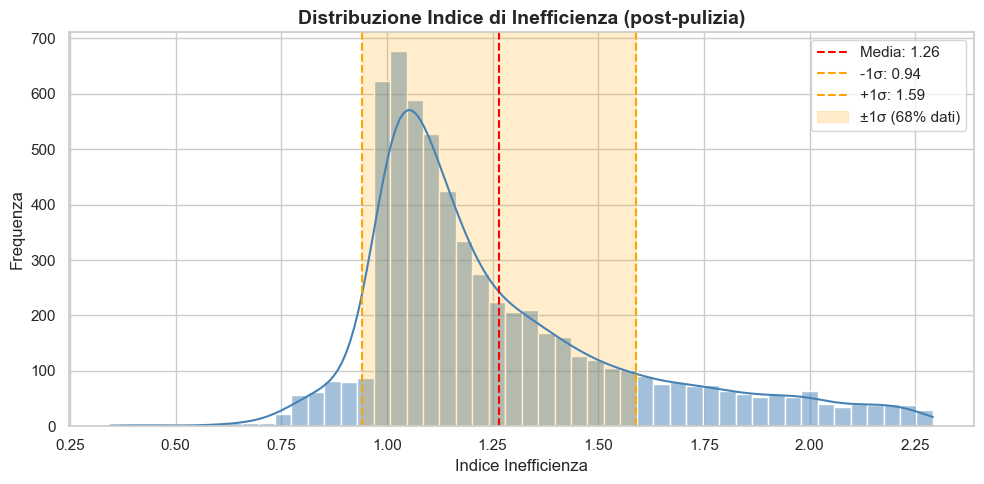

In [ ]:
# La distribuzione è pulita, senza outlier patologici. 
# La curva KDE sovrapposta mostra la forma reale. 
# La linea rossa indica la media. 
# Il cleaning IQR ha funzionato.

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df["Indice_Inefficienza"], bins=50, kde=True, color="steelblue", ax=ax)

media = df["Indice_Inefficienza"].mean()
std = df["Indice_Inefficienza"].std()

ax.set_title("Distribuzione Indice di Inefficienza (post-pulizia)", fontsize=14, fontweight="bold")
ax.set_xlabel("Indice Inefficienza")
ax.set_ylabel("Frequenza")
ax.axvline(media, color="red", linestyle="--", label=f"Media: {df['Indice_Inefficienza'].mean():.2f}")
ax.axvline(media - std, color="orange", linestyle="--", linewidth=1.5, label=f"-1σ: {media-std:.2f}")
ax.axvline(media + std, color="orange", linestyle="--", linewidth=1.5, label=f"+1σ: {media+std:.2f}")
ax.axvspan(media - std, media + std, alpha=0.2, color="orange", label=f"±1σ (68% dati)")
ax.legend()
plt.tight_layout()
plt.show()

## Boxplot for machine

C:\Users\filge\AppData\Local\Temp\ipykernel_19968\2772063351.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


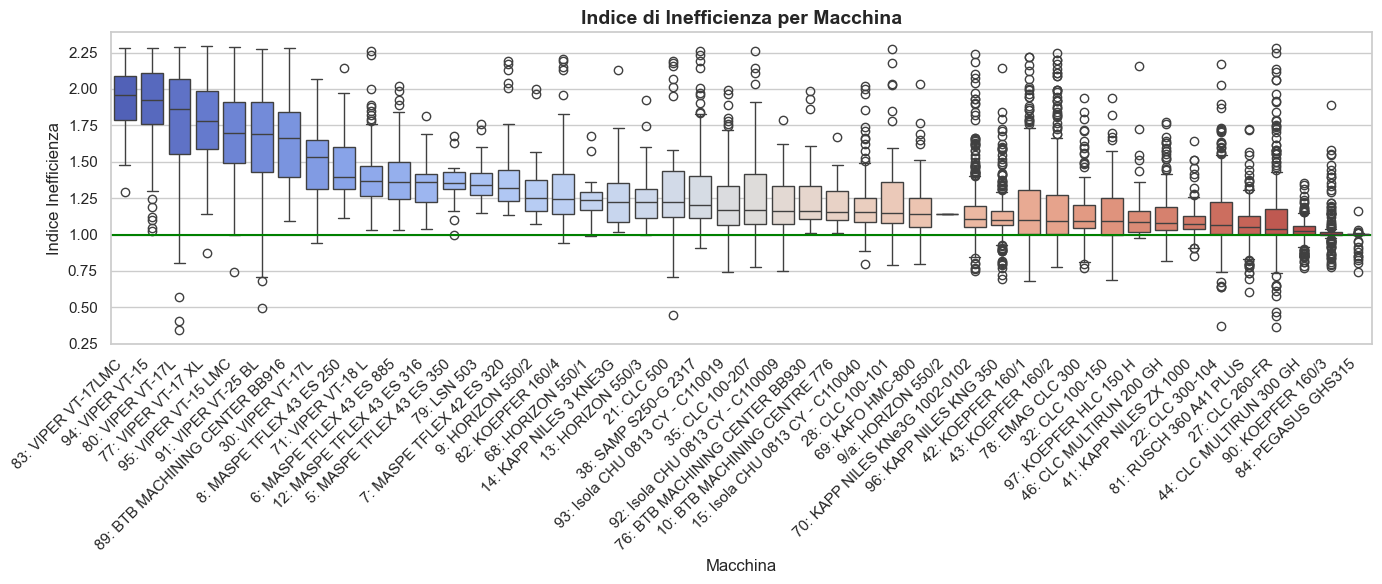

In [ ]:
# Quali macchine hanno mediana alta (inefficienti in media) 
# e quali hanno box largo (instabili/variabili).
# Utile per scegliere la macchina target del modello ML.
# Ordina per mediana decrescente

order = (
    df.groupby("Descrizione Macchina")["Indice_Inefficienza"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="Descrizione Macchina",
    y="Indice_Inefficienza",
    order=order,
    palette="coolwarm",
    ax=ax
)

ax.axhline(y=1.0, color="green", linestyle="-", label="Tempo teorico (1.00)")

ax.set_title("Indice di Inefficienza per Macchina", fontsize=14, fontweight="bold")
ax.set_xlabel("Macchina")
ax.set_ylabel("Indice Inefficienza")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Number of observations per machine (bar chart)

C:\Users\filge\AppData\Local\Temp\ipykernel_19968\639020767.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


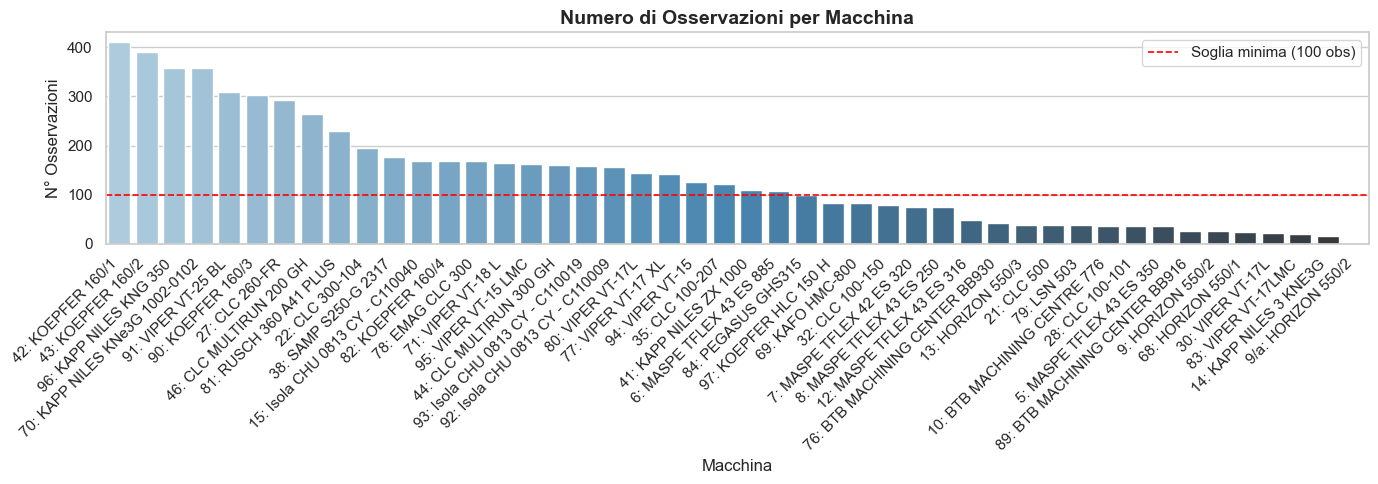

In [ ]:
# Quante osservazioni ha ogni macchina. 
# La linea rossa evidenzia la soglia minima per cui un modello ML è statisticamente affidabile. 
# Macchine sotto soglia vanno escluse.

obs_per_machine = (
    df.groupby("Descrizione Macchina")
    .size()
    .reset_index(name="N_Osservazioni")
    .sort_values("N_Osservazioni", ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 5))

bars = sns.barplot(
    data=obs_per_machine,
    x="Descrizione Macchina",
    y="N_Osservazioni",
    palette="Blues_d",
    ax=ax
)

ax.axhline(100, color="red", linestyle="--", linewidth=1.2, label="Soglia minima (100 obs)")
ax.set_title("Numero di Osservazioni per Macchina", fontsize=14, fontweight="bold")
ax.set_xlabel("Macchina")
ax.set_ylabel("N° Osservazioni")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()